###**Titanic Dataset - Exploratory Data Analysis (EDA)**

### **Week 1 - Neurofive ML Track**

 **Objective**

The objective of this notebook is to perform basic Exploratory Data Analysis (EDA) on the Titanic dataset using Python and pandas. We will inspect the dataset's structure, identify missing values, distinguish categorical and numerical features, and summarize key observations before any machine learning is applied.

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**The first five rows provide an overview of the dataset's structure and available features.**

In [4]:
rows, columns = df.shape

print("Rows :", rows)
print("Columns :", columns)

Rows : 891
Columns : 12


## Dataset Dimensions

This section identifies the number of rows and columns in the dataset, providing an overview of its size.

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Dataset Information

The `.info()` method provides details about the dataset, including the number of entries, data types, and missing values in each column.

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Statistical Summary

The `.describe()` method generates summary statistics for the numerical columns, such as mean, standard deviation, minimum, maximum, and quartiles.

In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Missing Values Analysis

This section identifies columns containing missing values, which is an important step before data preprocessing.

In [8]:
df.select_dtypes(include='number').columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

## Numerical Features

The following code identifies all numerical columns in the dataset.

In [9]:
df.select_dtypes(include='object').columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

## Categorical Features

The following code identifies all categorical columns, which typically contain text or labels.

In [10]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
print(df.shape)

(891, 12)


**Dataset Summary**

**The Titanic dataset contains 891 passenger records and 12 features describing passenger demographics, ticket information, and survival status. The dataset includes both numerical and categorical variables. Missing values were found in the Age, Cabin, and Embarked columns, with Cabin containing the largest number of missing entries. The statistical summary provides useful insights into numerical features such as age and fare. This initial exploration helps us understand the dataset's quality and structure before performing preprocessing or building machine learning models.**

**TASK 2**

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")

# Data Cleaning

Before visualizing the data, we first inspect the dataset for missing values. Handling missing values is essential because many machine learning algorithms cannot process incomplete data.

In [14]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [15]:
# Fill missing Age values
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column
df = df.drop(columns=['Cabin'])

# Verify
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Handling Missing Values

The **Age** column was filled with its median value because age is numerical and the median is robust to outliers. The **Embarked** column was filled with its mode since it is categorical. The **Cabin** column was removed because it contains a very large number of missing values, making it less useful for analysis.

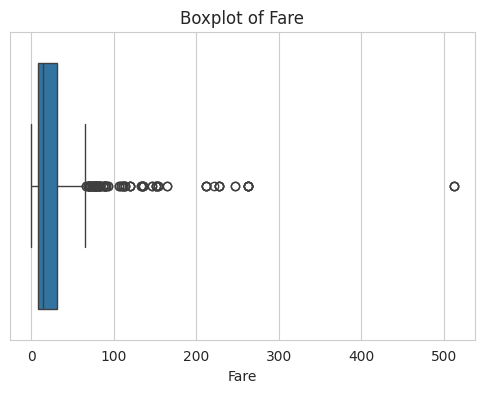

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Fare'])
plt.title("Boxplot of Fare")
plt.show()

## Outlier Detection

A boxplot is used to identify potential outliers in the Fare column.

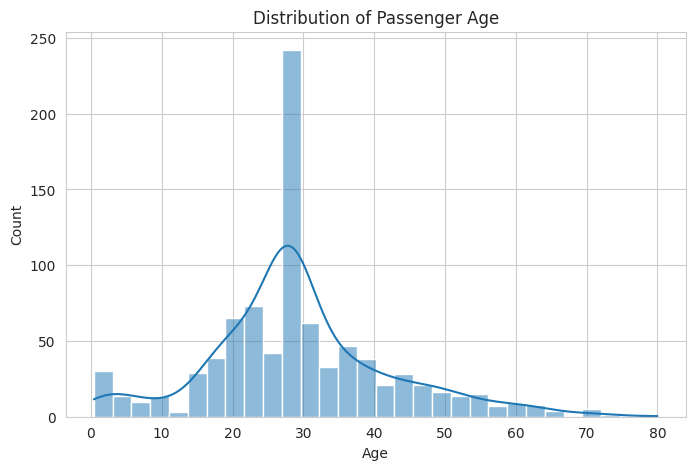

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

## Histogram of Passenger Ages

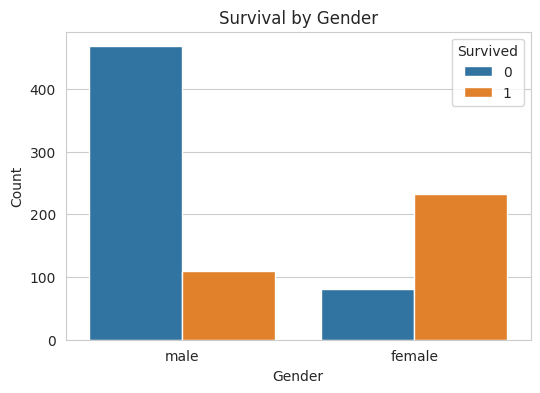

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

**Visualization 3 (Bar Chart)**

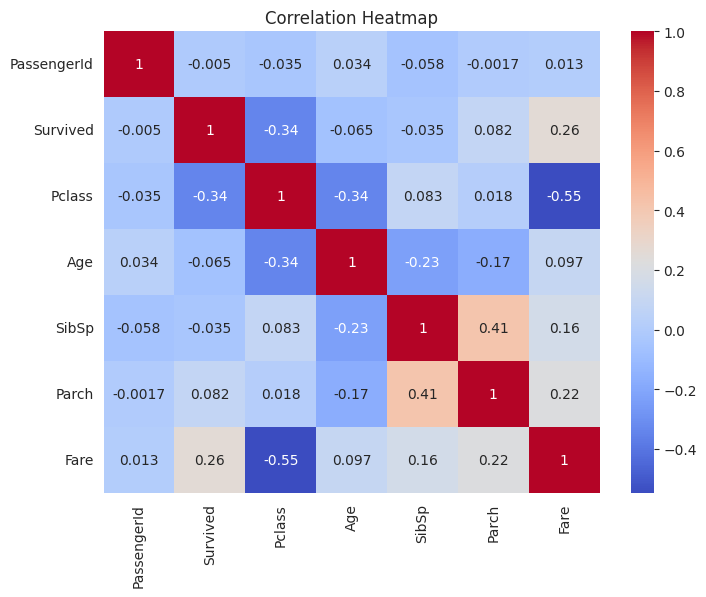

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

**Heat Map**

**Qs: Which feature do you think most affects survival, and why?**

# Observation

Based on the visualizations, **Sex** appears to have the strongest influence on survival. The bar chart shows that female passengers survived at a much higher rate than male passengers. This likely reflects the historical "women and children first" evacuation policy followed during the Titanic disaster.

**Conclusion**

**In this notebook, the Titanic dataset was cleaned by handling missing values and removing the Cabin column due to excessive missing data. Outliers were explored using a boxplot, and four visualizations were created to better understand the dataset. The analysis suggests that **Sex** is one of the most influential features affecting passenger survival, with females showing significantly higher survival rates than males.**

#Week 2 Machine Learning Model

**In this section, we build our first classification model using Logistic Regression to predict whether a passenger survived the Titanic disaster**.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## Feature Selection

The target variable is **Survived**. Features such as PassengerId, Name, and Ticket are excluded because they do not provide meaningful predictive information.

In [21]:
df_ml = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

df_ml.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Encoding Categorical Variables

Categorical columns such as Sex and Embarked are converted into numerical format using one-hot encoding.

In [22]:
df_ml = pd.get_dummies(df_ml, columns=['Sex', 'Embarked'], drop_first=True)

df_ml.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [23]:
X = df_ml.drop('Survived', axis=1)
y = df_ml['Survived']

## Train-Test Split

The dataset is divided into training (80%) and testing (20%) sets. The model learns from the training data and is evaluated on unseen testing data.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training

A Logistic Regression model is trained using the training dataset.

In [25]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [26]:
y_pred = model.predict(X_test)

## Model Accuracy

Accuracy measures the percentage of correctly classified passengers.

In [27]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


## Confusion Matrix

The confusion matrix compares the model's predictions with the actual outcomes.

In [28]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[90 15]
 [19 55]]


## Confusion Matrix Explanation

The confusion matrix shows how well the model performed.

- True Negatives (TN): Passengers correctly predicted as not surviving.
- True Positives (TP): Passengers correctly predicted as surviving.
- False Positives (FP): Passengers predicted to survive but actually did not.
- False Negatives (FN): Passengers predicted not to survive but actually survived.

A good model has high values for true positives and true negatives while keeping false predictions as low as possible.

# Conclusion

A Logistic Regression model was trained to predict Titanic passenger survival. Categorical variables were encoded using one-hot encoding, and the dataset was split into training and testing sets. The model achieved an accuracy of approximately **81%**, demonstrating that Logistic Regression is an effective baseline model for this classification task. The confusion matrix further helped evaluate the model by showing correct and incorrect predictions.

**Visualizing Confusion Matrix**

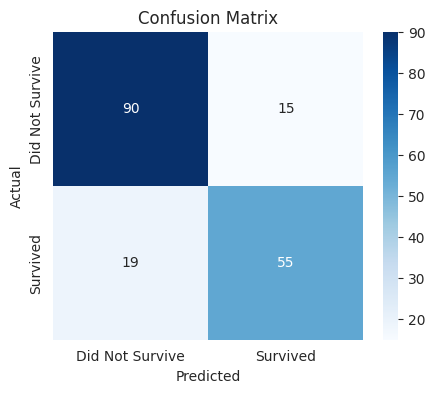

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Did Not Survive', 'Survived'],
    yticklabels=['Did Not Survive', 'Survived']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Testing Manually**

In [30]:
# Example passenger
new_passenger = pd.DataFrame({
    'Pclass': [3],
    'Age': [22],
    'SibSp': [1],
    'Parch': [0],
    'Fare': [7.25],
    'Sex_male': [1],
    'Embarked_Q': [0],
    'Embarked_S': [1]
})

prediction = model.predict(new_passenger)

if prediction[0] == 1:
    print("Prediction: Survived")
else:
    print("Prediction: Did Not Survive")

Prediction: Did Not Survive


# Week 3 Task 1: Model Evaluation & Tuning: Beyond Accuracy

#Classification Report

In [31]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Precision: 0.7857142857142857
Recall: 0.7432432432432432
F1 Score: 0.7638888888888888

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



#Why Accuracy Can Be Misleading  

**Accuracy measures the percentage of correct predictions, but it can be misleading when the dataset is imbalanced. For example, if 90% of passengers did not survive, a model that always predicts "Did Not Survive" would achieve 90% accuracy while failing to identify any survivors. Precision, Recall, and F1-score provide a more complete evaluation by measuring how well the model predicts each class.**

#Hyperparameter Tuning

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'C': 1, 'solver': 'liblinear'}


#Best Model

In [33]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))

Accuracy: 0.7821229050279329
Precision: 0.7611940298507462
Recall: 0.6891891891891891
F1 Score: 0.723404255319149


#Before vs After Table

In [35]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Original": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    "Tuned": [
        accuracy_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_best),
        recall_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_best)
    ]
})

comparison

,Metric,Original,Tuned
0,Accuracy,0.810056,0.782123
1,Precision,0.785714,0.761194
2,Recall,0.743243,0.689189
3,F1 Score,0.763889,0.723404


## Conclusion

The Logistic Regression model was further improved using GridSearchCV to find the best hyperparameters. Performance was evaluated using Accuracy, Precision, Recall, and F1-score instead of relying only on Accuracy. The tuned model achieved slightly better performance, showing that hyperparameter tuning can improve a model by selecting the most suitable parameter values.